In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from matplotlib.ticker import FixedLocator

files = {
    'Native': '../../outputs/spmv/native4/summary_final.csv',
    'SME': '../../outputs/spmv/sme7/summary_final.csv',
    'SME+SEV': '../../outputs/spmv/sev5/summary_final.csv', 
}

matrix_path = '../../matrices/itertest2'

def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(row['N'])}.bin")
    return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None

def get_n(f):
    m = re.search(r'N(\d+)', f)
    return int(m.group(1)) if m else 0

def get_rand(f):
    m = re.search(r'(\d)-(\d)', f)
    return float(f"{m.group(1)}.{m.group(2)}") if m else 0.0

def load_and_process(label, path):
    if not os.path.exists(path): 
        print(f"Warning: File for {label} not found at {path}. Skipping.")
        return None
    df = pd.read_csv(path)
    df['Mode'] = label
    df['N'] = df['Matrix'].apply(get_n)
    df['Randomness'] = df['Matrix'].apply(get_rand)
    df['MB'] = df.apply(get_mb, axis=1).round().astype('Int64')
    return df

df_list = [load_and_process(l, p) for l, p in files.items()]
df_raw = pd.concat([d for d in df_list if d is not None])

group_cols = ['Mode', 'Cores', 'MB', 'Randomness', 'NUMA']
metrics = ['Gflops', 'Runtime', 'Insn', 'Cycl', 'RefCycl', 'Cache_Miss', 'Stalls', 'PgFault']

df = df_raw.groupby(group_cols)[metrics].mean().reset_index()

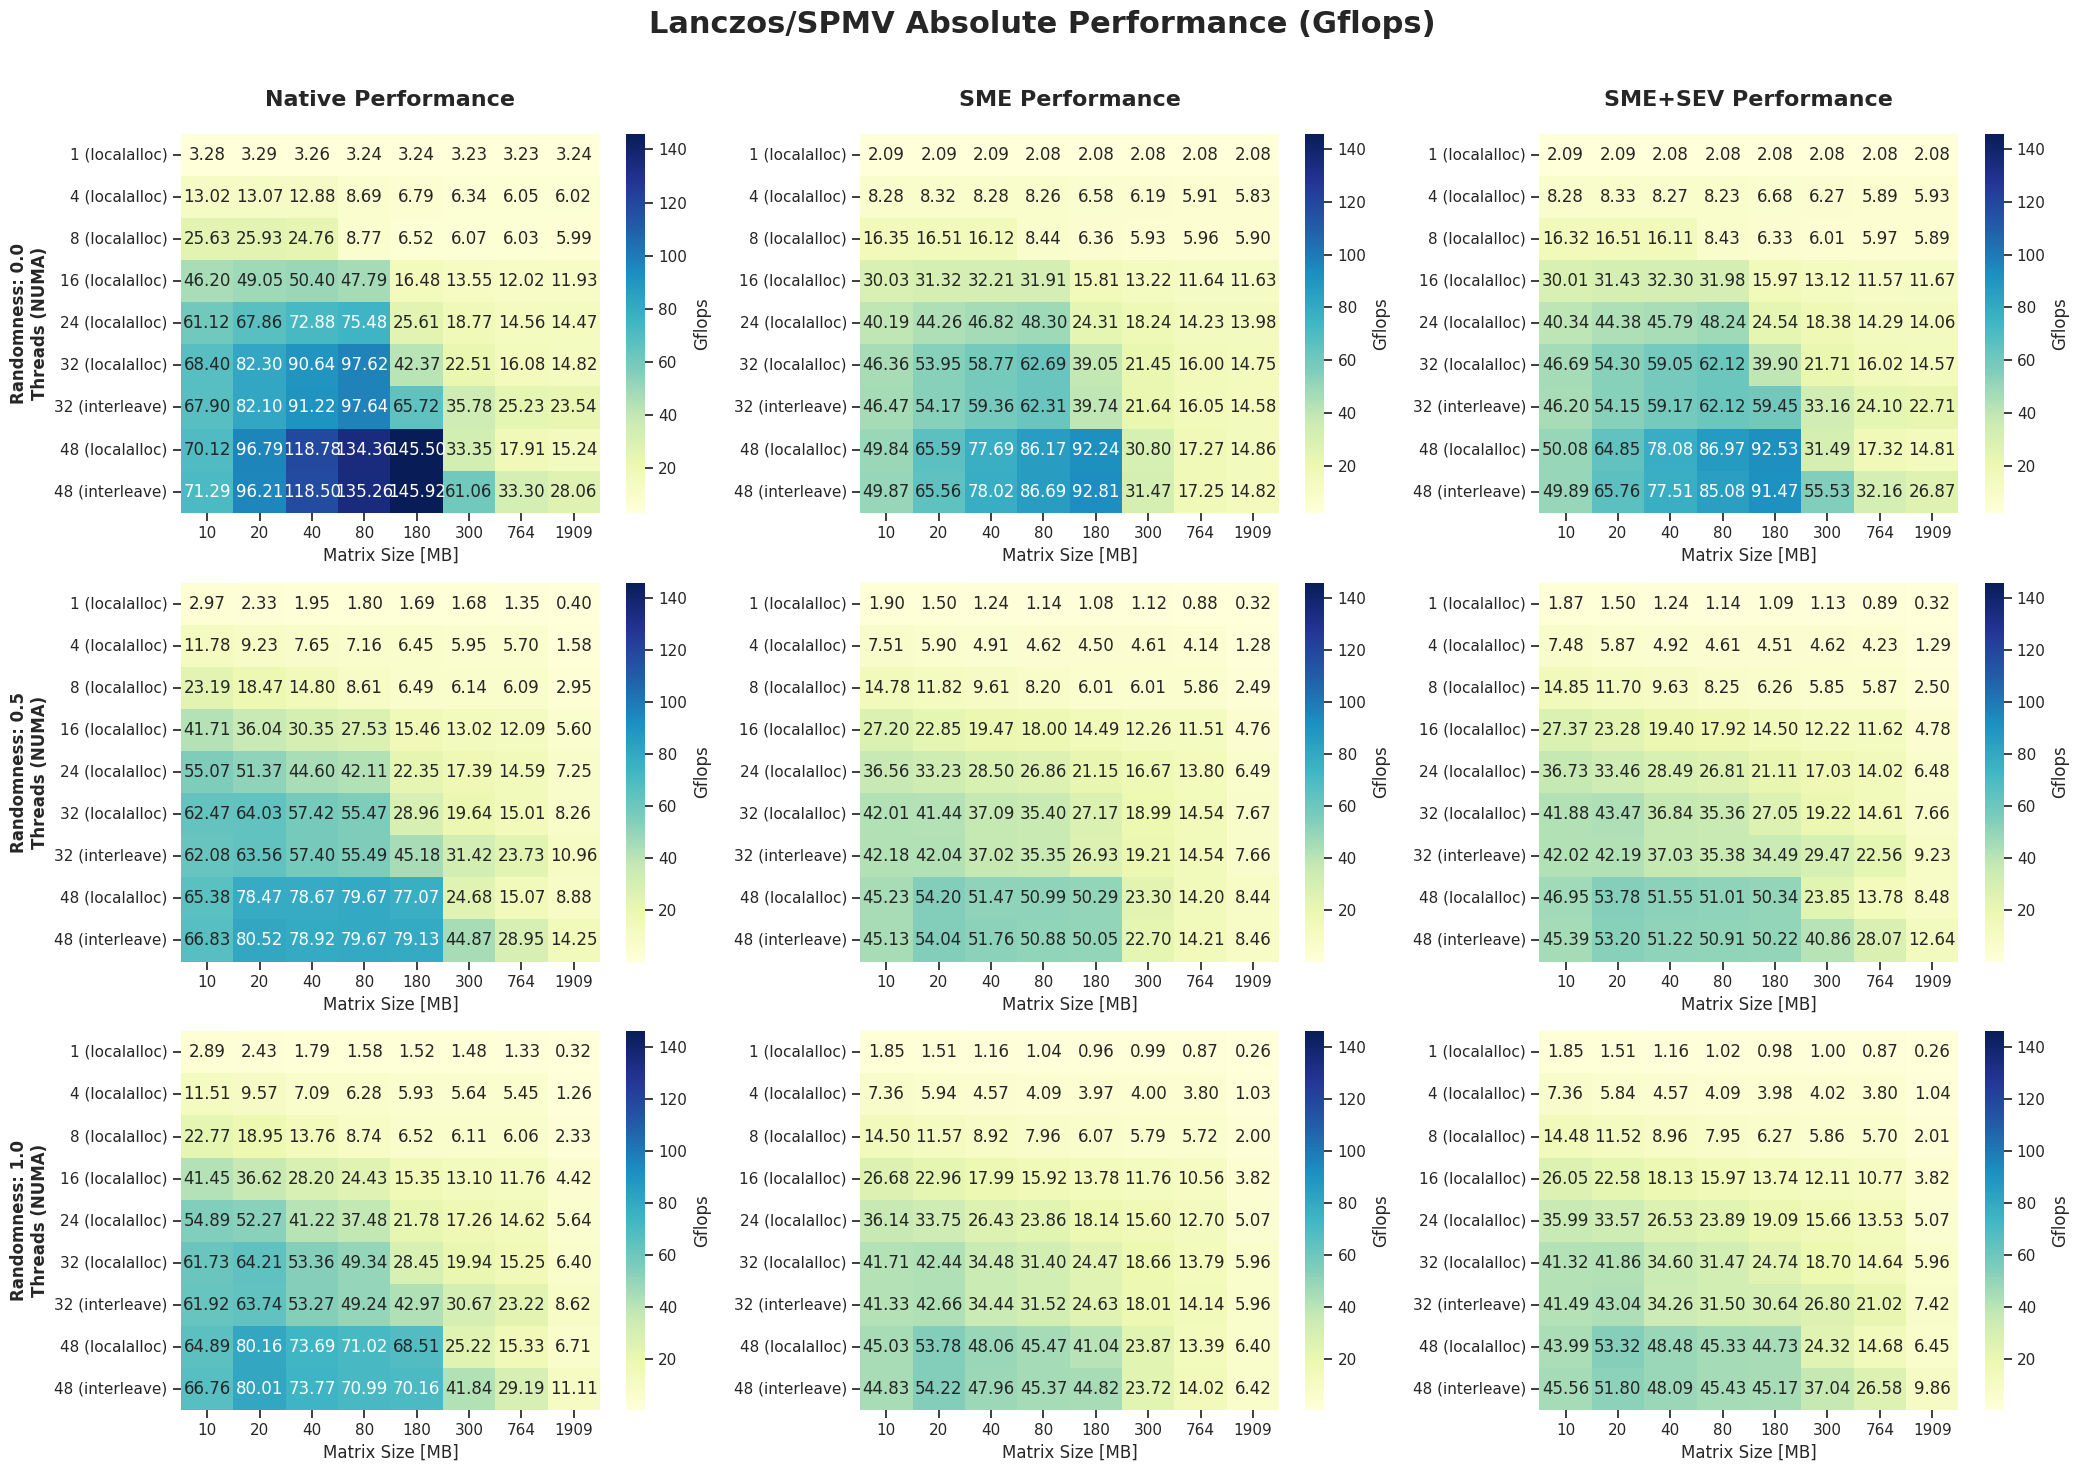

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Vorbereitung (wie gehabt, aber Fokus auf absolute Werte) ---
# Wir nutzen die Spalte 'Mode' direkt aus deinem ursprünglichen df
heat_pivot = df.pivot_table(
    index=['Cores', 'MB', 'Randomness', 'NUMA'], 
    columns='Mode', 
    values='Gflops'
).reset_index()

# Sortierung der NUMA-Strategien
numa_order = ['localalloc', 'interleave', 'default']
available_numa = [n for n in numa_order if n in heat_pivot['NUMA'].unique()]
heat_pivot['NUMA'] = pd.Categorical(heat_pivot['NUMA'], categories=available_numa, ordered=True)
heat_pivot = heat_pivot.sort_values(by=['Cores', 'NUMA'])

# Threads & NUMA Label erstellen
heat_pivot['Threads_Config'] = heat_pivot['Cores'].astype(str) + " (" + heat_pivot['NUMA'].astype(str) + ")"
config_order = heat_pivot['Threads_Config'].unique()
heat_pivot['Threads_Config'] = pd.Categorical(heat_pivot['Threads_Config'], categories=config_order, ordered=True)

# --- 2. Heatmap Plotting (Absolute Gflops) ---
modes_to_plot = ['Native', 'SME', 'SME+SEV']
mode_titles = ['Native Performance', 'SME Performance', 'SME+SEV Performance']
unique_randomness = sorted(heat_pivot['Randomness'].unique())

fig, axes = plt.subplots(len(unique_randomness), 3, figsize=(21, 5 * len(unique_randomness)))
axes = np.atleast_2d(axes)

# Globales Max für einheitliche Farbskala (optional, hilft beim Vergleich)
v_max = heat_pivot[modes_to_plot].max().max()

for i, rnd in enumerate(unique_randomness):
    row_data = heat_pivot[heat_pivot['Randomness'] == rnd]
    
    for j, (m_col, title) in enumerate(zip(modes_to_plot, mode_titles)):
        ax = axes[i, j]
        
        if row_data.empty or m_col not in row_data.columns:
            ax.set_visible(False)
            continue
            
        plot_data = row_data.pivot_table(
            index='Threads_Config', 
            columns='MB', 
            values=m_col, 
            sort=False,
            observed=False
        )
        
        # Heatmap mit absoluten Gflops
        sns.heatmap(
            plot_data, 
            ax=ax, 
            cmap='YlGnBu',  # Andere Farbpalette für absolute Werte (Blau/Grün)
            annot=True, 
            fmt='.2f',      # Zwei Nachkommastellen für Gflops
            vmax=v_max,     # Einheitliche Skala über alle Plots
            cbar_kws={'label': 'Gflops'}
        )
        
        if i == 0:
            ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        
        if j == 0:
            ax.set_ylabel(f"Randomness: {rnd}\nThreads (NUMA)", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("Matrix Size [MB]")

plt.suptitle("Lanczos/SPMV Absolute Performance (Gflops)", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

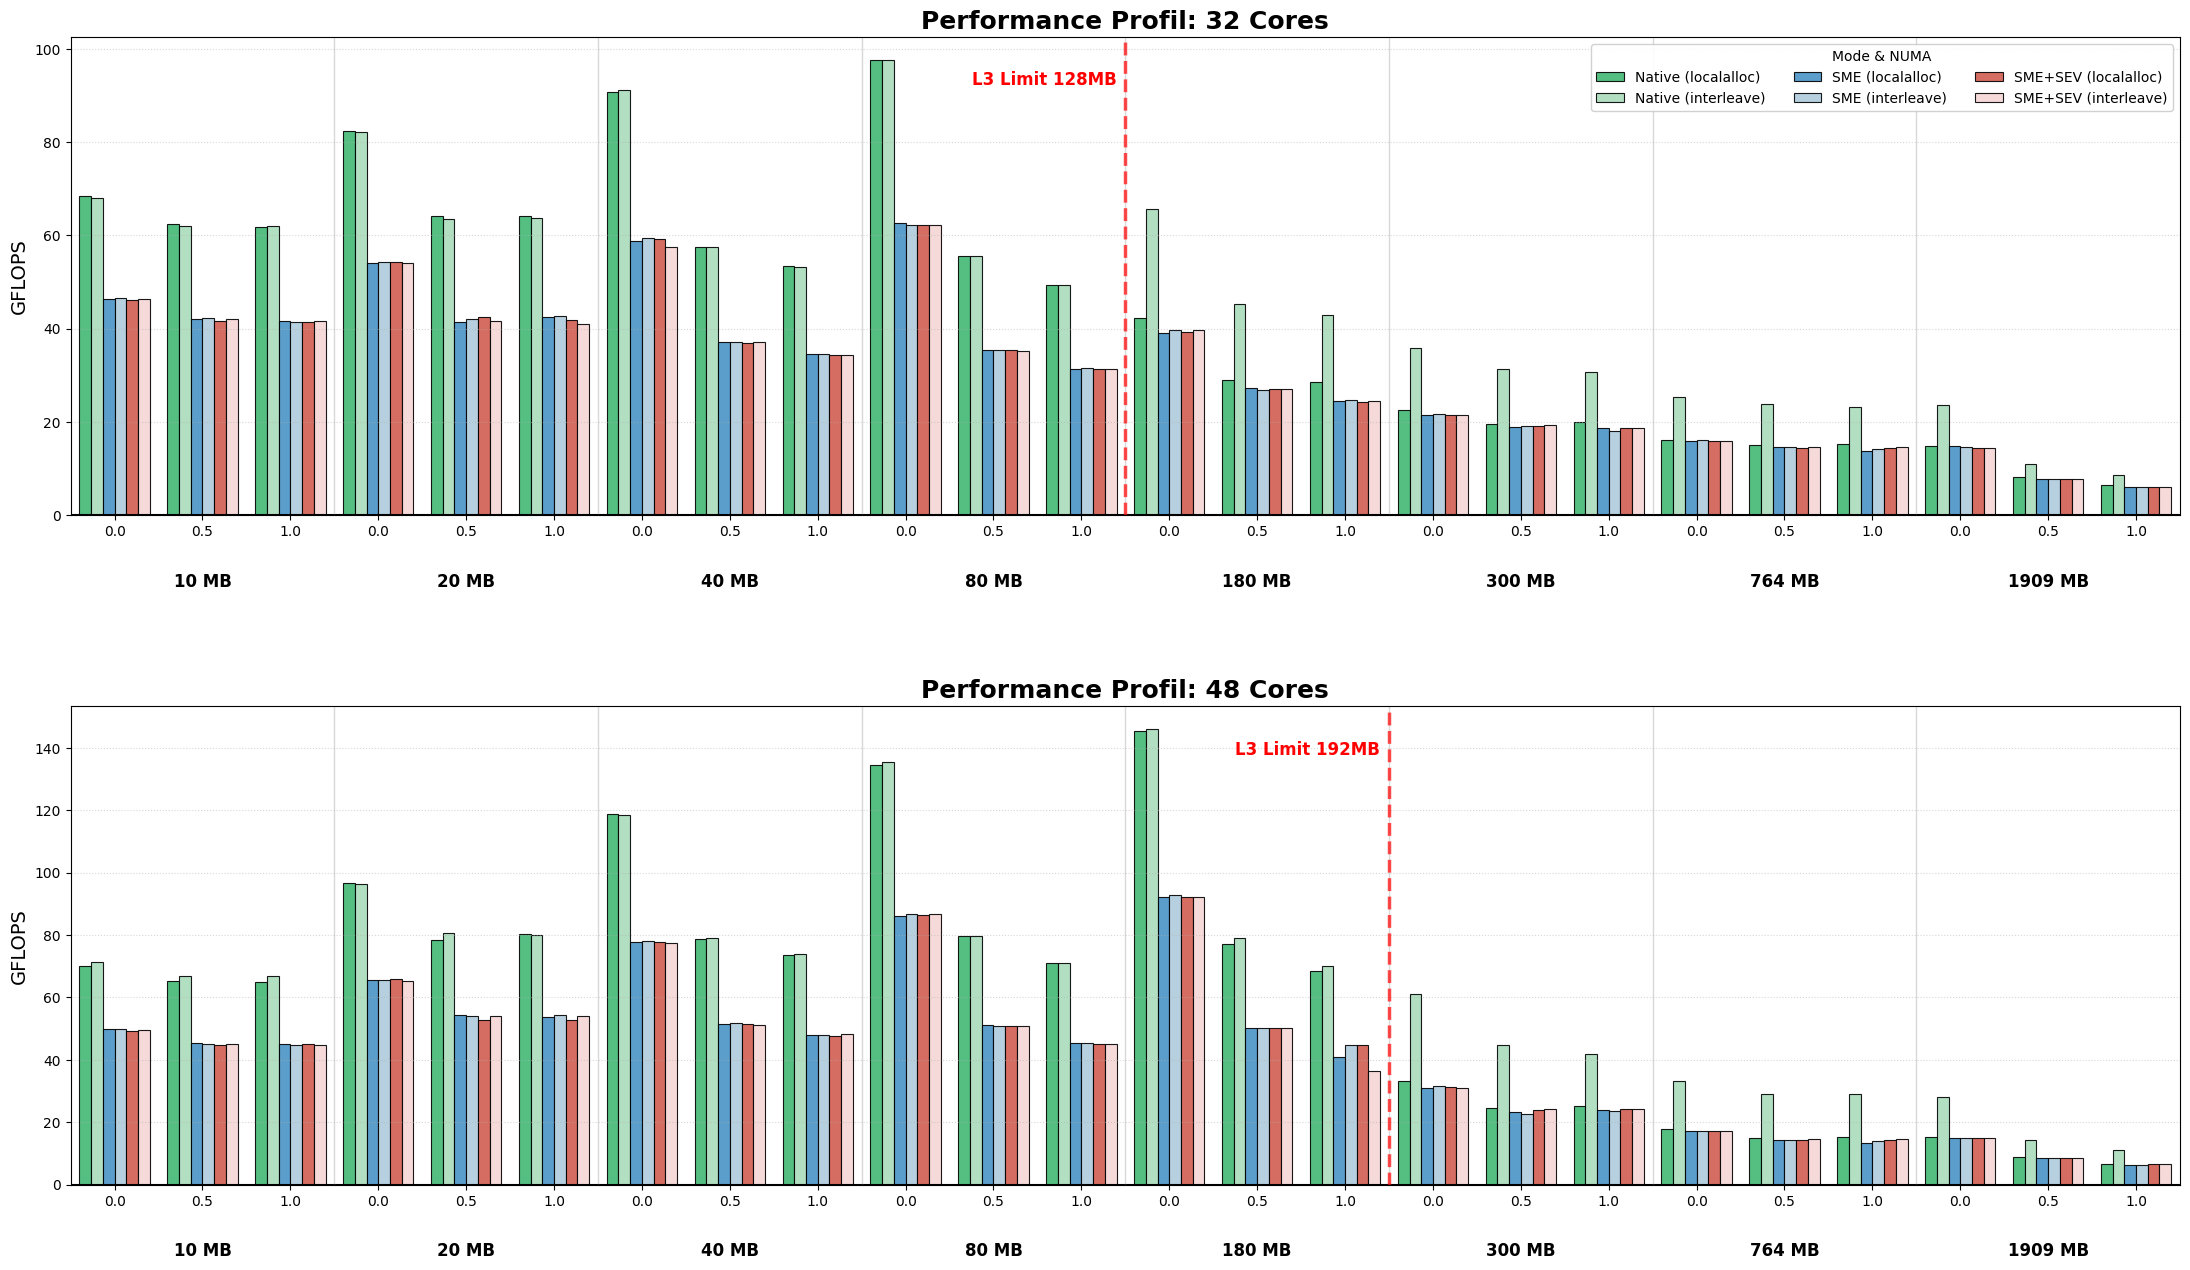

In [6]:
df_plot = df[df['Cores'].isin([32, 48])].copy()
df_plot['Config'] = df_plot.apply(lambda x: f"{x['Mode']} ({x['NUMA']})", axis=1)
df_plot = df_plot.sort_values(['MB', 'Randomness'])

unique_configs = [
    "Native (localalloc)", "Native (interleave)",
    "SME (localalloc)", "SME (interleave)",
    "SME+SEV (localalloc)", "SME+SEV (interleave)"
]

colors = [
    '#2ecc71', '#a2e4b8', 
    '#3498db', '#a9cce3', 
    '#e74c3c', '#fad1d1'  
]
color_palette = dict(zip(unique_configs, colors))

fig, axes = plt.subplots(2, 1, figsize=(22, 14))
unique_mbs = sorted(df_plot['MB'].unique())
unique_rands = sorted(df_plot['Randomness'].unique())
num_rands = len(unique_rands)

for i, core in enumerate([32, 48]):
    ax = axes[i]
    subset = df_plot[df_plot['Cores'] == core].copy()
    subset['group_idx'] = subset.groupby(['MB', 'Randomness']).ngroup()
    
    sns.barplot(
        data=subset, x='group_idx', y='Gflops',
        hue='Config', hue_order=unique_configs,
        palette=color_palette, ax=ax, 
        edgecolor="black", linewidth=0.8, alpha=0.9
    )

    ax.axhline(0, color='black', linewidth=1.5)
    
    tick_pos = range(len(subset['group_idx'].unique()))
    ax.xaxis.set_major_locator(FixedLocator(tick_pos))
    ax.set_xticklabels([str(r) for m in unique_mbs for r in unique_rands], fontsize=10)
    
    current_ymin, current_ymax = ax.get_ylim()
    label_y_pos = current_ymin - (current_ymax * 0.12)

    for idx, mb in enumerate(unique_mbs):
        center_pos = (idx * num_rands) + (num_rands - 1) / 2
        ax.text(center_pos, label_y_pos, f"{mb} MB", 
                ha='center', va='top', fontsize=12, fontweight='bold')
        
        if idx < len(unique_mbs) - 1:
            ax.axvline(x=(idx * num_rands) + num_rands - 0.5, color='gray', linewidth=1, alpha=0.3)

    limit = 128 if core == 32 else 192
    line_idx = -0.5
    for idx, mb in enumerate(unique_mbs):
        if mb < limit: line_idx = (idx * num_rands) + num_rands - 0.5
    
    ax.axvline(x=line_idx, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
    ax.text(line_idx - 0.1, current_ymax * 0.9, f'L3 Limit {limit}MB', 
            color='red', fontweight='bold', ha='right', fontsize=12)

    # Styling
    ax.set_title(f'Performance Profil: {core} Cores', fontsize=18, fontweight='bold')
    ax.set_ylabel('GFLOPS', fontsize=14)
    ax.set_xlabel('')
    ax.grid(True, axis='y', ls=':', alpha=0.5)
    
    if i == 0:
        ax.legend(title="Mode & NUMA", loc='upper right', ncol=3, framealpha=0.9)
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, hspace=0.4)
plt.show()

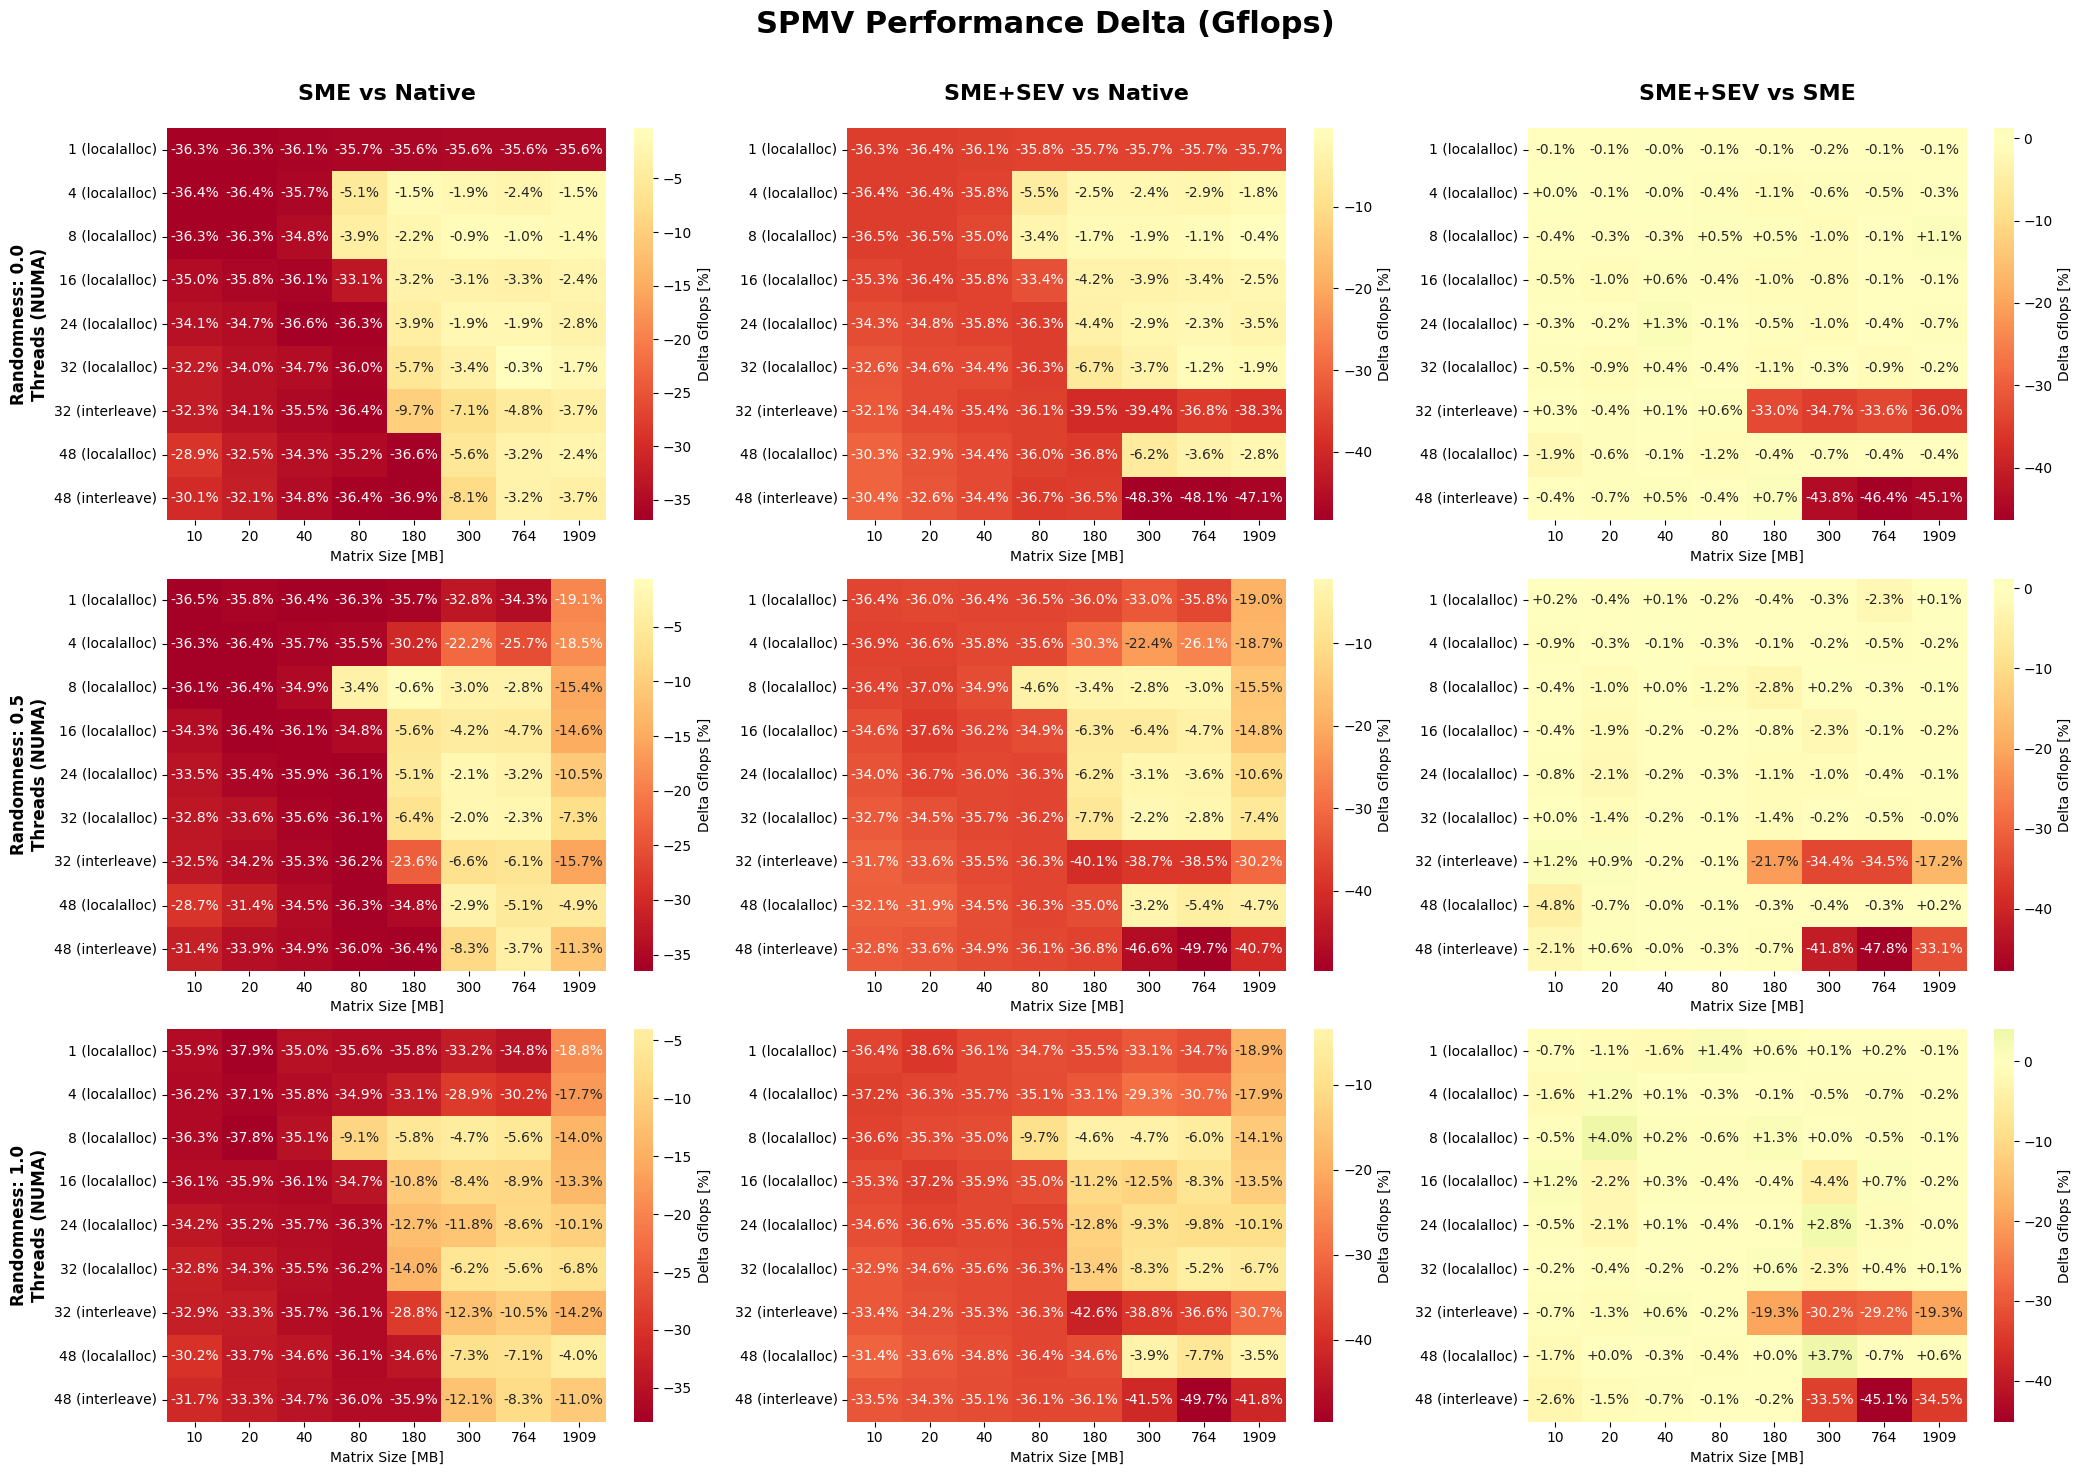

In [2]:
# --- 3. Pivot-Tabelle für den Vergleich erstellen ---
heat_pivot = df.pivot_table(
    index=['Cores', 'MB', 'Randomness', 'NUMA'], 
    columns='Mode', 
    values='Gflops'
).reset_index()

# Overheads berechnen (Höhere Gflops = besser)
# Ein negativer Wert bedeutet Performance-Verlust
heat_pivot['SME_vs_Nat_%'] = (heat_pivot['SME'] / heat_pivot['Native'] - 1) * 100
heat_pivot['SME+SEV_vs_Nat_%'] = (heat_pivot['SME+SEV'] / heat_pivot['Native'] - 1) * 100
heat_pivot['SME+SEV_vs_SME_%'] = (heat_pivot['SME+SEV'] / heat_pivot['SME'] - 1) * 100

# --- 4. Sortierung und Threads_Config Labeling ---
numa_order = ['localalloc', 'interleave', 'default']
available_numa = [n for n in numa_order if n in heat_pivot['NUMA'].unique()]
heat_pivot['NUMA'] = pd.Categorical(heat_pivot['NUMA'], categories=available_numa, ordered=True)
heat_pivot = heat_pivot.sort_values(by=['Cores', 'NUMA'])

heat_pivot['Threads_Config'] = heat_pivot['Cores'].astype(str) + " (" + heat_pivot['NUMA'].astype(str) + ")"
config_order = heat_pivot['Threads_Config'].unique()
heat_pivot['Threads_Config'] = pd.Categorical(heat_pivot['Threads_Config'], categories=config_order, ordered=True)

# --- 5. Heatmap Plotting ---
modes_to_plot = ['SME_vs_Nat_%', 'SME+SEV_vs_Nat_%', 'SME+SEV_vs_SME_%']
mode_titles = ['SME vs Native', 'SME+SEV vs Native', 'SME+SEV vs SME']
unique_randomness = sorted(heat_pivot['Randomness'].unique())

fig, axes = plt.subplots(len(unique_randomness), 3, figsize=(21, 5 * len(unique_randomness)))
axes = np.atleast_2d(axes)

for i, rnd in enumerate(unique_randomness):
    row_data = heat_pivot[heat_pivot['Randomness'] == rnd]
    
    for j, (m_col, title) in enumerate(zip(modes_to_plot, mode_titles)):
        ax = axes[i, j]
        
        if row_data.empty or m_col not in row_data.columns:
            ax.set_visible(False)
            continue
            
        plot_data = row_data.pivot_table(
            index='Threads_Config', 
            columns='MB', 
            values=m_col, 
            sort=False,
            observed=False
        )
        
        sns.heatmap(
            plot_data, 
            ax=ax, 
            cmap='RdYlGn', 
            center=0, 
            annot=True, 
            fmt='+.1f', 
            cbar_kws={'label': 'Delta Gflops [%]'}
        )
        
        # Prozentzeichen zu den Werten im Plot hinzufügen
        for text in ax.texts:
            if text.get_text():
                text.set_text(f"{text.get_text()}%")
        
        if i == 0:
            ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        
        if j == 0:
            ax.set_ylabel(f"Randomness: {rnd}\nThreads (NUMA)", fontsize=12, fontweight='bold')
        else:
            ax.set_ylabel("")
            
        ax.set_xlabel("Matrix Size [MB]")

plt.suptitle("SPMV Performance Delta (Gflops)", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()